In [2]:
# Cell 1 - Imports
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import json
import os
import sys

# Add model folder to path
sys.path.append(str(Path("..").resolve() / "model"))

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
print(f"✅ GPU name: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
✅ GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# Cell 2 - Load dataset
BASE_DIR = Path("..").resolve()
SPLITS_DIR = BASE_DIR / "data" / "splits"

# Load class info
with open(BASE_DIR / "utils" / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

NUM_CLASSES = dataset_info["num_classes"]
CLASS_NAMES = dataset_info["class_names"]

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load datasets
train_dataset = datasets.ImageFolder(
    root=str(SPLITS_DIR / "train"),
    transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    root=str(SPLITS_DIR / "val"),
    transform=val_transforms
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

print(f"✅ Dataset loaded!")
print(f"  Train: {len(train_dataset)} images")
print(f"  Val:   {len(val_dataset)} images")
print(f"  Classes: {NUM_CLASSES}")

✅ Dataset loaded!
  Train: 20302 images
  Val:   4349 images
  Classes: 20


In [4]:
# Cell 3 - Build Model
class SkinDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModel, self).__init__()
        
        # Load pretrained EfficientNet
        self.backbone = models.efficientnet_b0(weights='DEFAULT')
        
        # Freeze early layers
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False
        
        # Get number of features
        num_features = self.backbone.classifier[1].in_features
        
        # Remove original classifier
        self.backbone.classifier = nn.Identity()
        
        # Disease classification head
        self.disease_head = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
        # Severity head
        self.severity_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
    
    def forward(self, x):
        features     = self.backbone(x)
        disease_out  = self.disease_head(features)
        severity_out = self.severity_head(features)
        return disease_out, severity_out

# Create model and move to GPU
model = SkinDiseaseModel(num_classes=NUM_CLASSES).to(device)

print(f"✅ Model created!")
print(f"  Device: {device}")
print(f"  Classes: {NUM_CLASSES}")

✅ Model created!
  Device: cuda
  Classes: 20


In [5]:
# Cell 4 - Setup training
EPOCHS        = 30
LEARNING_RATE = 0.001
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Loss functions
disease_criterion  = nn.CrossEntropyLoss()
severity_criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

print(f"✅ Training setup complete!")
print(f"\n📊 Training Config:")
print(f"  Epochs:        {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Optimizer:     Adam")
print(f"  Scheduler:     StepLR (step=10, gamma=0.5)")
print(f"  Checkpoint:    {CHECKPOINT_DIR}")

✅ Training setup complete!

📊 Training Config:
  Epochs:        30
  Learning rate: 0.001
  Optimizer:     Adam
  Scheduler:     StepLR (step=10, gamma=0.5)
  Checkpoint:    C:\Users\shruti\Desktop\project\Skin-Disease Predictor\checkpoints


In [6]:
# Cell 5 - Training loop
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # ── TRAINING ──
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, 
                                desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        disease_out, severity_out = model(images)

        # Severity labels based on disease class
        severity_labels = (labels % 3).to(device)

        # Combined loss
        loss = disease_criterion(disease_out, labels) + \
               0.3 * severity_criterion(severity_out, severity_labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = disease_out.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total += labels.size(0)

    train_acc  = 100 * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # ── VALIDATION ──
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader,
                                    desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images = images.to(device)
            labels = labels.to(device)

            disease_out, severity_out = model(images)
            severity_labels = (labels % 3).to(device)

            loss = disease_criterion(disease_out, labels) + \
                   0.3 * severity_criterion(severity_out, severity_labels)

            val_loss += loss.item()
            _, predicted = disease_out.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc  = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\n📊 Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 
                   CHECKPOINT_DIR / "best_model.pth")
        print(f"  ✅ Best model saved! Val Acc: {val_acc:.2f}%")

    scheduler.step()

print(f"\n🎉 Training Complete!")
print(f"  Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30 [Train]:   0%|          | 0/635 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/136 [00:00<?, ?it/s]


📊 Epoch 1/30
  Train Loss: 1.2669 | Train Acc: 60.69%
  Val Loss:   0.9415 | Val Acc:   70.57%
  ✅ Best model saved! Val Acc: 70.57%


Epoch 2/30 [Train]:   0%|          | 0/635 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/136 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/136 [00:00<?, ?it/s]


📊 Epoch 29/30
  Train Loss: 0.2545 | Train Acc: 92.05%
  Val Loss:   0.7455 | Val Acc:   83.19%


Epoch 30/30 [Train]:   0%|          | 0/635 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/136 [00:00<?, ?it/s]


📊 Epoch 30/30
  Train Loss: 0.2485 | Train Acc: 92.33%
  Val Loss:   0.7647 | Val Acc:   82.59%

🎉 Training Complete!
  Best Val Accuracy: 83.19%


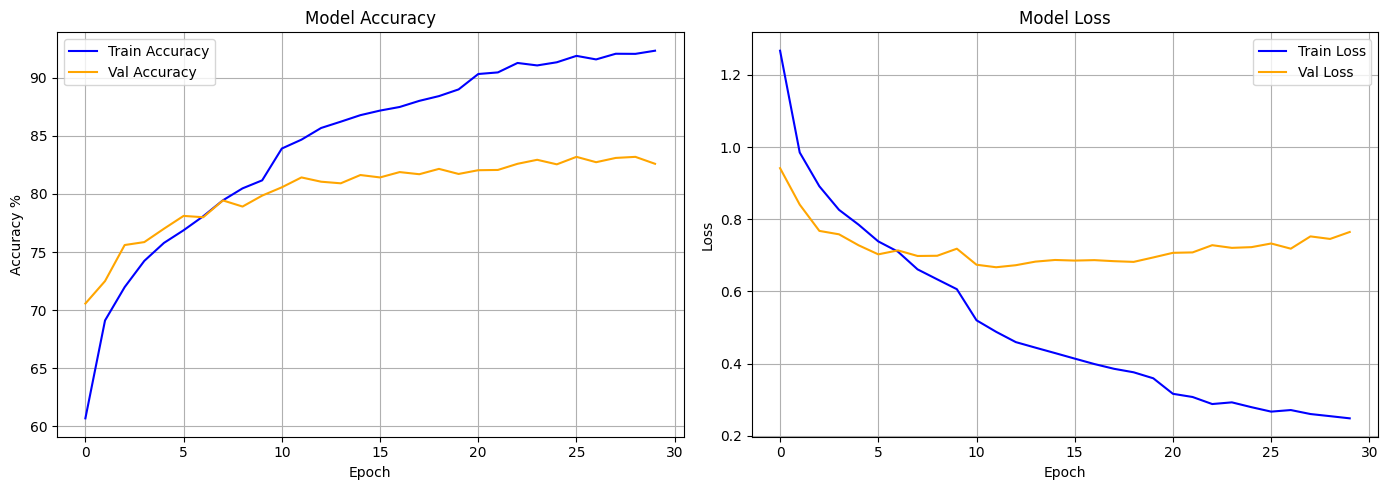

✅ Graphs saved!


In [7]:
# Cell 6 - Plot training graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy graph
ax1.plot(train_accs, label='Train Accuracy', color='blue')
ax1.plot(val_accs, label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy %')
ax1.legend()
ax1.grid(True)

# Loss graph
ax2.plot(train_losses, label='Train Loss', color='blue')
ax2.plot(val_losses, label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(str(BASE_DIR / "reports" / "training_graphs.png"))
plt.show()
print("✅ Graphs saved!")